# Homework 5

## Question 1

### Part (a)

This section computes the constant-model market impact curve for ZNH4 over selected February 2024 trading days.

The workflow is:
- connect to the kdb server
- for each date, as-of join trades with quotes to get midpoint at each trade time
- map trade aggressor flags to +1 and -1
- compute signed midpoint changes for lags 1 to 50 and aggregate across days
- average by lag and plot the resulting impact curve

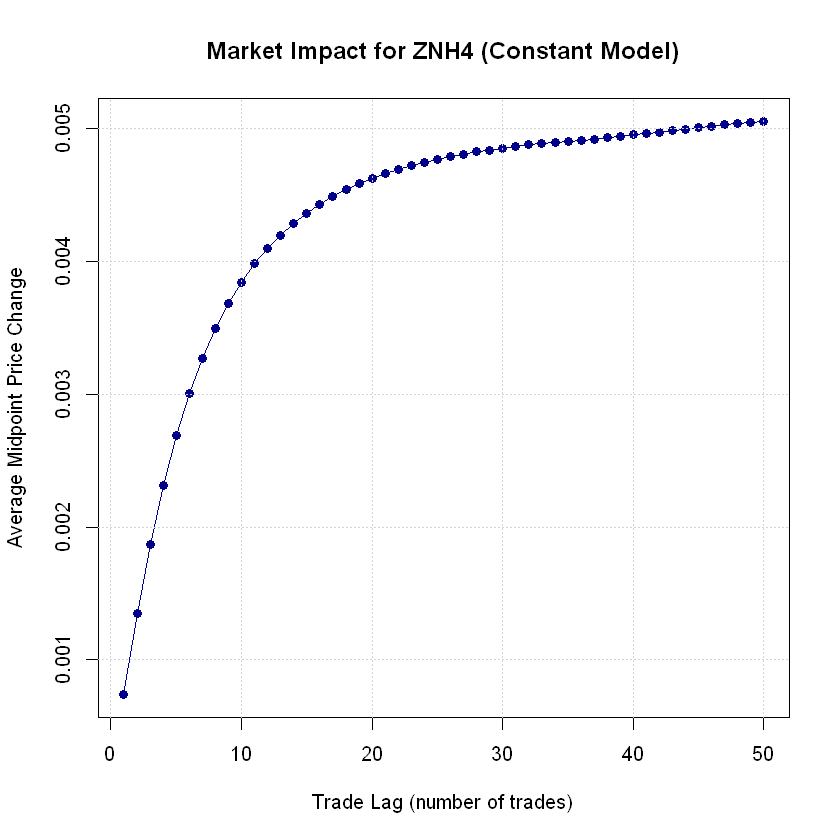

In [13]:
library(rkdb)

host <- "hfm.princeton.edu"
port <- 6007

h <- open_connection(host, port)

sym <- "ZNH4"
dates <- c("2024.02.05", "2024.02.06", "2024.02.07", "2024.02.08", "2024.02.09",
           "2024.02.12", "2024.02.13", "2024.02.14", "2024.02.15", "2024.02.16",
           "2024.02.20", "2024.02.21", "2024.02.22", "2024.02.23")

max_lag <- 50
total_impact <- numeric(max_lag)
total_count <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    for (k in 1:max_lag) {
      idx <- which(!is.na(df$sign))
      idx <- idx[idx + k <= nrow(df)]
      
      impact_k <- df$sign[idx] * (df$midpoint[idx + k] - df$midpoint[idx])
      valid_impacts <- impact_k[!is.na(impact_k)]
      
      total_impact[k] <- total_impact[k] + sum(valid_impacts)
      total_count[k] <- total_count[k] + length(valid_impacts)
    }
  }
}

average_impact <- total_impact / total_count

plot(1:max_lag, average_impact, type = "o", pch = 16, col = "darkblue",
     xlab = "Trade Lag (number of trades)", 
     ylab = "Average Midpoint Price Change",
     main = paste("Market Impact for", sym, "(Constant Model)"))
grid()

### Part (b) Market Impact by Trade Size

To evaluate the importance of trade size, we modify our previous query to also extract the size of each trade. We then compute the median trade size for each day. 

Trades are split into two categories: those strictly greater than the median size, and those less than or equal to the median size. We calculate the forward price change for both subsets independently and plot them on the same graph to visually inspect if larger trades carry more information and therefore cause a larger permanent market impact.

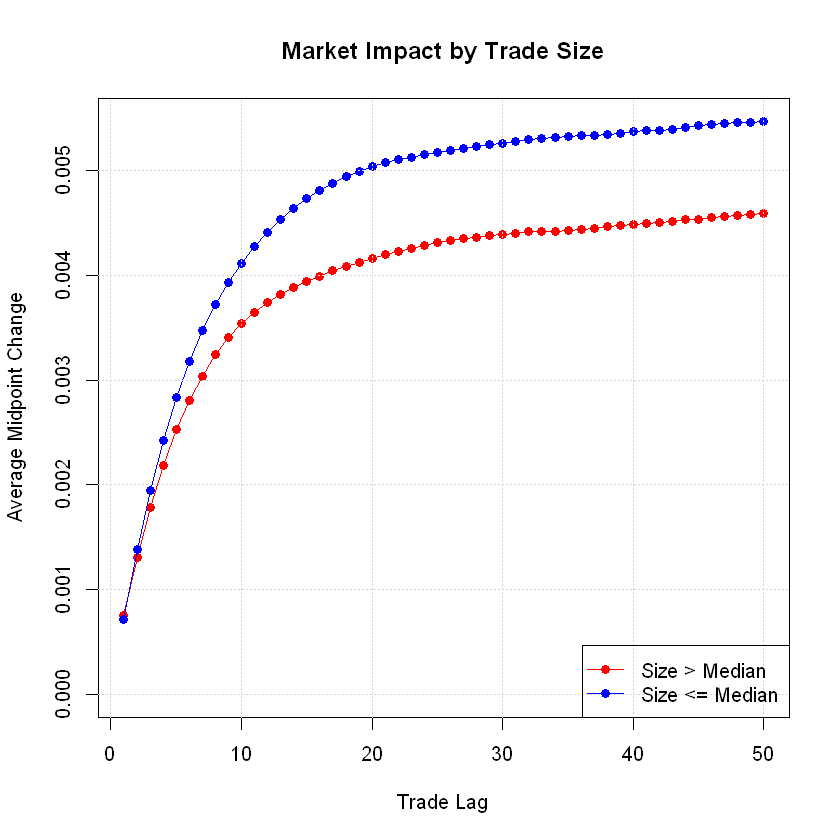

In [15]:
max_lag <- 50
impact_small <- numeric(max_lag)
count_small <- numeric(max_lag)
impact_large <- numeric(max_lag)
count_large <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, size:siz, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    med_size <- median(df$size, na.rm = TRUE)
    
    idx_valid <- which(!is.na(df$sign))
    idx_small <- idx_valid[df$size[idx_valid] <= med_size]
    idx_large <- idx_valid[df$size[idx_valid] > med_size]
    
    for (k in 1:max_lag) {
      idx_s_k <- idx_small[idx_small + k <= nrow(df)]
      imp_s <- df$sign[idx_s_k] * (df$midpoint[idx_s_k + k] - df$midpoint[idx_s_k])
      valid_s <- imp_s[!is.na(imp_s)]
      impact_small[k] <- impact_small[k] + sum(valid_s)
      count_small[k] <- count_small[k] + length(valid_s)
      
      idx_l_k <- idx_large[idx_large + k <= nrow(df)]
      imp_l <- df$sign[idx_l_k] * (df$midpoint[idx_l_k + k] - df$midpoint[idx_l_k])
      valid_l <- imp_l[!is.na(imp_l)]
      impact_large[k] <- impact_large[k] + sum(valid_l)
      count_large[k] <- count_large[k] + length(valid_l)
    }
  }
}

avg_impact_small <- impact_small / count_small
avg_impact_large <- impact_large / count_large

plot(1:max_lag, avg_impact_large, type = "o", pch = 16, col = "red",
     xlab = "Trade Lag", ylab = "Average Midpoint Change",
     main = "Market Impact by Trade Size", ylim = range(c(avg_impact_small, avg_impact_large, 0)))
lines(1:max_lag, avg_impact_small, type = "o", pch = 16, col = "blue")
grid()
legend("bottomright", legend = c("Size > Median", "Size <= Median"), 
       col = c("red", "blue"), lty = 1, pch = 16)

### 1(c) Market Impact by Quote Size (Depth)

To test if trades sent into deeper markets have a smaller impact, we need to separate trades based on the quote size on the side of the market they executed against. 

A market buy order (aggr = B) executes against the ask, so the relevant depth is the ask size (asiz). A market sell order (aggr = S) executes against the bid, so the relevant depth is the bid size (bsiz). We extract these sizes, find the daily median depth, and split our trades into deep (above median) and shallow (below or equal to median) categories before computing the forward impact.

[1] 0

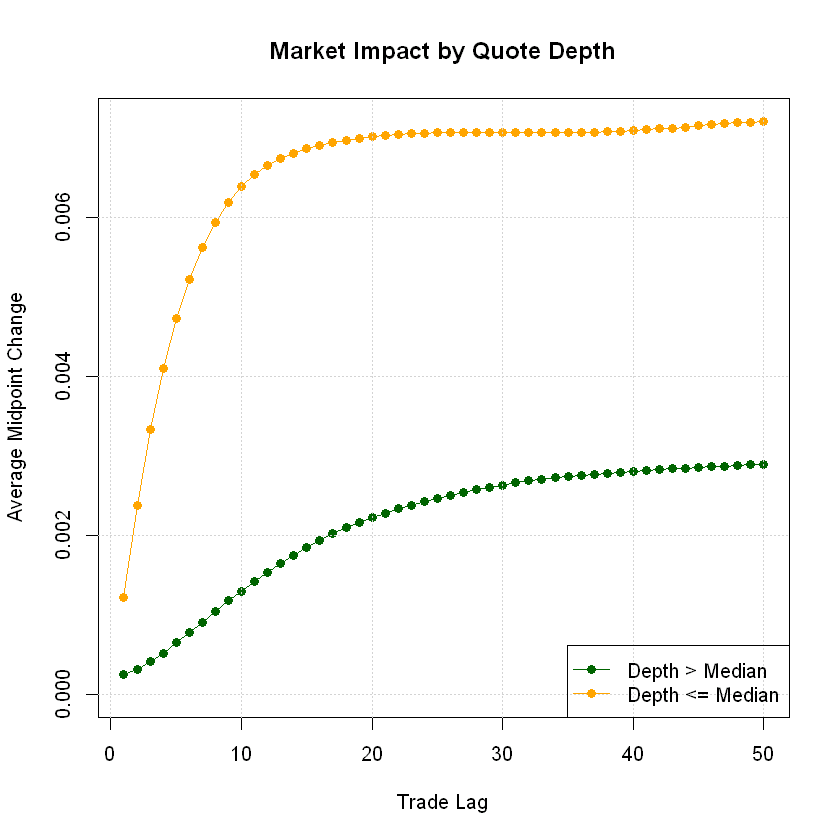

In [16]:
max_lag <- 50
impact_shallow <- numeric(max_lag)
count_shallow <- numeric(max_lag)
impact_deep <- numeric(max_lag)
count_deep <- numeric(max_lag)

for (d in dates) {
  q_str <- paste0(
    "aj[`time; ",
    "(select time, aggr from trade where date=", d, ", sym=`", sym, "); ",
    "(select time, bsiz, asiz, midpoint: 0.5*(bid+ask) from quote where date=", d, ", sym=`", sym, ")]"
  )
  
  df <- execute(h, q_str)
  
  if (nrow(df) > max_lag) {
    df$sign <- NA
    df$sign[df$aggr == "B"] <- 1
    df$sign[df$aggr == "S"] <- -1
    
    df$quote_depth <- NA
    df$quote_depth[df$aggr == "B"] <- df$asiz[df$aggr == "B"]
    df$quote_depth[df$aggr == "S"] <- df$bsiz[df$aggr == "S"]
    
    med_depth <- median(df$quote_depth, na.rm = TRUE)
    
    idx_valid <- which(!is.na(df$sign) & !is.na(df$quote_depth))
    idx_shallow <- idx_valid[df$quote_depth[idx_valid] <= med_depth]
    idx_deep <- idx_valid[df$quote_depth[idx_valid] > med_depth]
    
    for (k in 1:max_lag) {
      idx_s_k <- idx_shallow[idx_shallow + k <= nrow(df)]
      imp_s <- df$sign[idx_s_k] * (df$midpoint[idx_s_k + k] - df$midpoint[idx_s_k])
      valid_s <- imp_s[!is.na(imp_s)]
      impact_shallow[k] <- impact_shallow[k] + sum(valid_s)
      count_shallow[k] <- count_shallow[k] + length(valid_s)
      
      idx_d_k <- idx_deep[idx_deep + k <= nrow(df)]
      imp_d <- df$sign[idx_d_k] * (df$midpoint[idx_d_k + k] - df$midpoint[idx_d_k])
      valid_d <- imp_d[!is.na(imp_d)]
      impact_deep[k] <- impact_deep[k] + sum(valid_d)
      count_deep[k] <- count_deep[k] + length(valid_d)
    }
  }
}

avg_impact_shallow <- impact_shallow / count_shallow
avg_impact_deep <- impact_deep / count_deep

plot(1:max_lag, avg_impact_deep, type = "o", pch = 16, col = "darkgreen",
     xlab = "Trade Lag", ylab = "Average Midpoint Change",
     main = "Market Impact by Quote Depth", ylim = range(c(avg_impact_shallow, avg_impact_deep, 0)))
lines(1:max_lag, avg_impact_shallow, type = "o", pch = 16, col = "orange")
grid()
legend("bottomright", legend = c("Depth > Median", "Depth <= Median"),
       col = c("darkgreen", "orange"), lty = 1, pch = 16)